# Neural Receiver for SIMO-OFDM Link-Level Simulation

## Summary

This notebook studies a neural receiver for a SIMO-OFDM system using Sionna and PyTorch. The main workflow is:

1. Load libraries and Sionna components.
2. Define simulation parameters, resource grid, antenna setup, and channel configuration.
3. Define the neural receiver architecture using convolutional residual layers.
4. Define the end-to-end communication system, including transmitter, channel, baseline receivers, neural receiver, and decoder.
5. Evaluate baseline receivers using perfect CSI and LS channel estimation.
6. Load and evaluate the pretrained neural receiver.
7. Test neural receiver robustness across different CDL channel models.
8. Test neural receiver robustness under a larger delay spread.
9. Fine-tune the pretrained neural receiver for domain adaptation.
10. Study pruning and INT8 weight round-trip compression for the neural receiver.

The final section is a compression-error experiment. It does not implement true accelerated INT8 inference. Tt evaluates the BLER impact of pruning and quantizing weights for storage, then dequantizing them back into a runnable PyTorch model.


# Step 0: Load libraries and components

In [129]:
import sionna.phy

import torch
import gc
import numpy as np
import math
import torch.nn as nn
import torch.nn.functional as F

device = "cuda:0" if torch.cuda.is_available() else "cpu"
sionna.phy.config.device = device
sionna.phy.config.seed = 42
from sionna.phy import Block
from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, ResourceGridDemapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers
from sionna.phy.utils import ebnodb2no, insert_dims, expand_to_rank, sim_ber
from sionna.phy.mapping import Mapper, Demapper, BinarySource
from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder

General structures are as follow

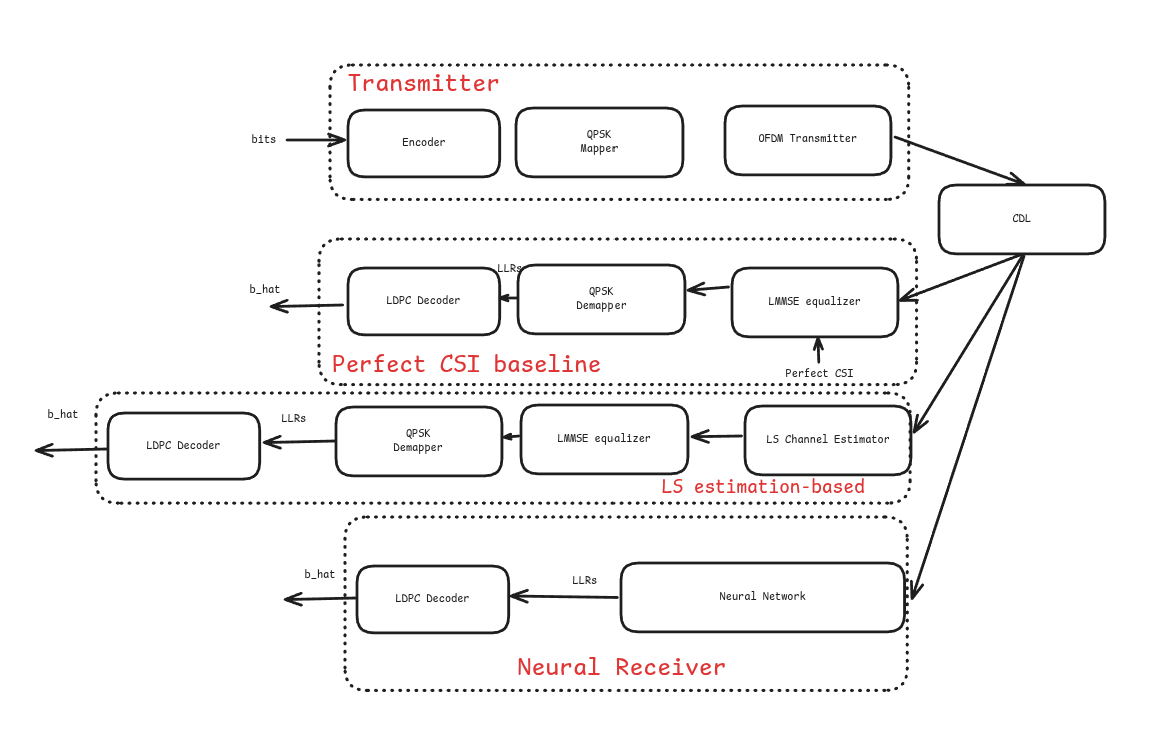
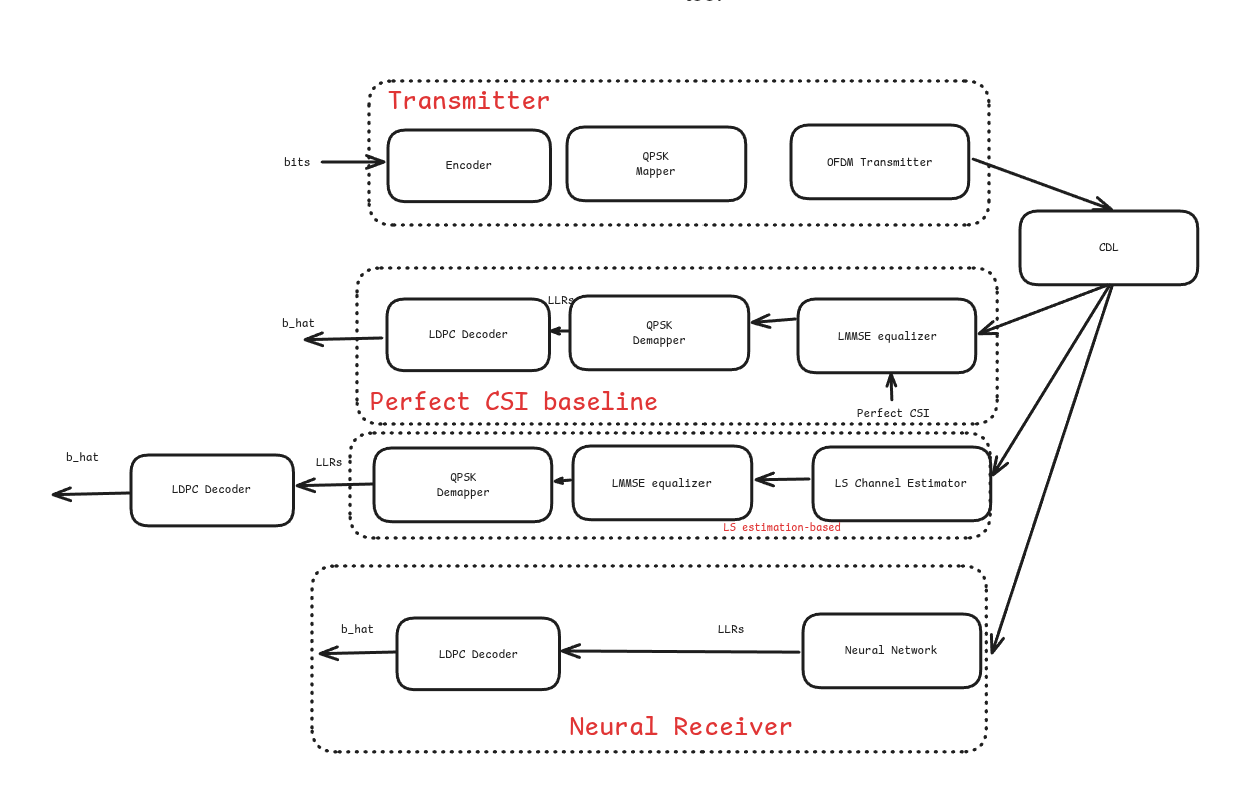

# Step 1: Load Parameters and Initialize Components

In [16]:
carrier_frequency = 3.5e9
delay_spread = 100e-9
cdl_model = "C"
speed = 10.0

# Range of SNR to train on
ebno_db_min = -5.0
ebno_db_max = 10.0

num_bits_per_symbol = 2
coderate = 0.5

num_conv_channels = 128

num_training_iterations = 30000
training_batch_size = 128
model_weights_path = "neural_receiver_weights"

result_filename = "neural_receiver_results"

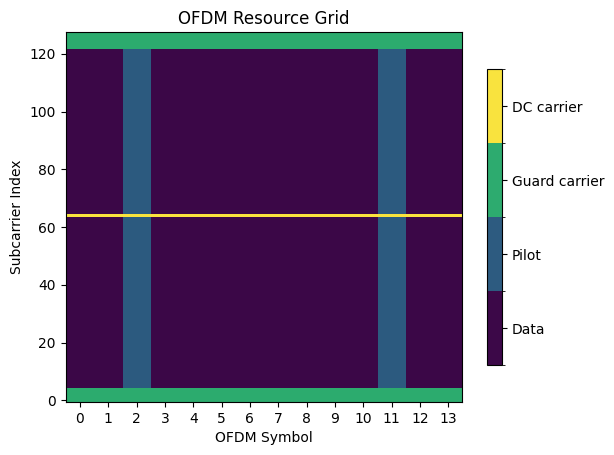

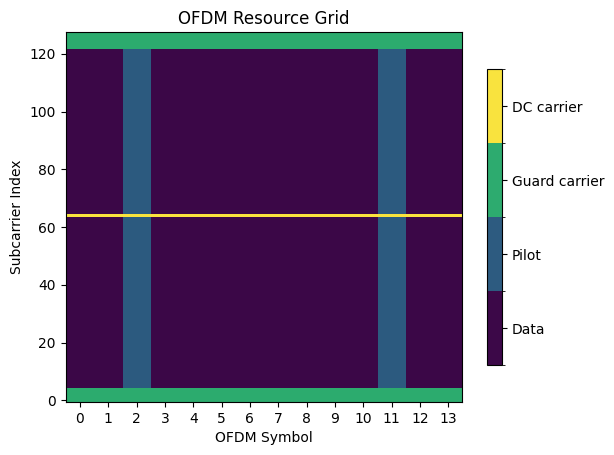

In [17]:
sm = StreamManagement(np.array([[1]]), 1)
rg = ResourceGrid(num_ofdm_symbols=14,
                  fft_size=128,
                  subcarrier_spacing=30e3,
                  pilot_ofdm_symbol_indices=[2, 11],
                  pilot_pattern="kronecker",
                  num_guard_carriers=[5, 6],
                  dc_null=True,
                  cyclic_prefix_length=5)
rg.show()

In [18]:
n = int(rg.num_data_symbols * num_bits_per_symbol)
k = int(coderate * n)

In [19]:
# 1 UT Antenna
ut_ant = Antenna(polarization="single",
                 polarization_type="V",
                 antenna_pattern="38.901",
                 carrier_frequency=carrier_frequency)
# 2 BS Antenna
bs_ant = AntennaArray(polarization="dual",
                      polarization_type="VH", # no need for cross if ut_ant is "V"
                      antenna_pattern="38.901",
                      carrier_frequency=carrier_frequency,
                      num_rows=1, num_cols=1)

# Step 2: Define the Neural Network

## Overview of the NN

The architecture of the NN is defined as the below diagram
- The complex resource grid is first separated to 5 channels (2 for real, complex values, 2 for 2 antennas, and 1 for noise).
- The input grids are then fed into a convolution to output 128 channels.
- The output is then fed through 4 ResLayer.
- The final output of the neural networks is 2 grids. Each grid holds 1 bit of the estimated symbol at the resource element.

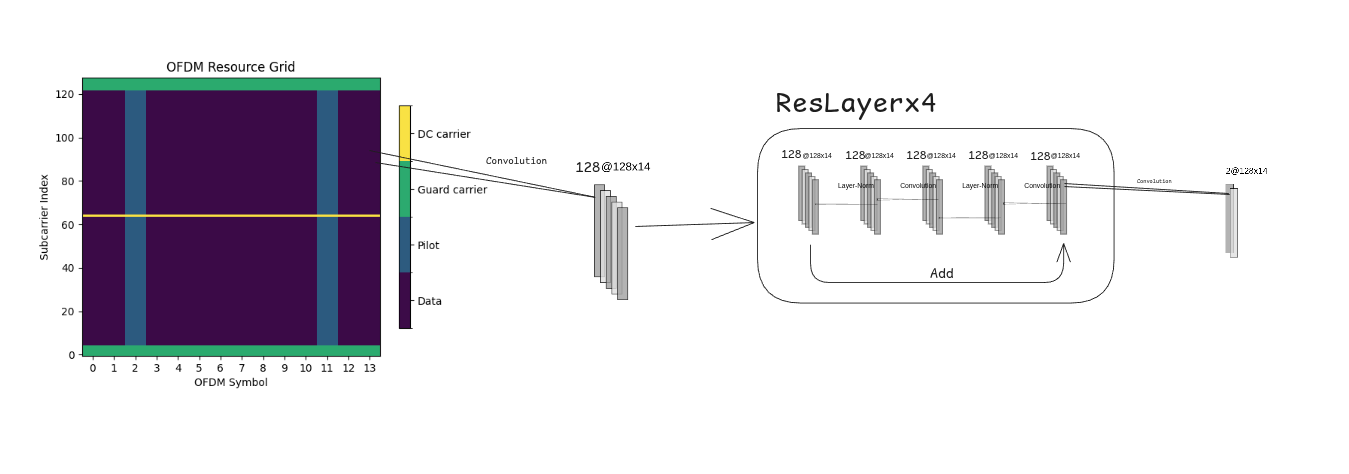

**Why choosing LayerNorm instead of BatchNorm as in normal ResNet**

Because this block wants to normalize each received sample independently, not using statistics from other samples in the mini-batch. This neural receiver is processing a single OFDM resource grid realization per sample.




## Define ResLayer



In [20]:
class ResLayer(nn.Module):
    def __init__(self, num_conv_channels):
        super().__init__()
        self.layer_norm1 = nn.LayerNorm([num_conv_channels, rg.num_ofdm_symbols, rg.fft_size])
        self.conv1 = nn.Conv2d(in_channels=num_conv_channels,
                               out_channels=num_conv_channels,
                               kernel_size=3,
                               padding=1)
        self.layer_norm2 = nn.LayerNorm([num_conv_channels, rg.num_ofdm_symbols, rg.fft_size])
        self.conv2 = nn.Conv2d(in_channels=num_conv_channels,
                               out_channels=num_conv_channels,
                               kernel_size=3,
                               padding=1)
    def forward(self, inputs):
        z = self.layer_norm1(inputs)
        z = F.relu(z)
        z = self.conv1(z)
        z = self.layer_norm2(z)
        z = F.relu(z)
        z = self.conv2(z)
        z = z + inputs
        return z

## Define the Neural Network as the Neural Receiver

In [21]:
class NRX(nn.Module):
    def __init__(self, num_conv_channels, num_bits_per_symbol):
        super().__init__()
        self.num_bits_per_symbol = num_bits_per_symbol
        num_input_channels = 2 * 2 + 1 # 2 antennas, real+imag, plus noise
        self.input_conv = nn.Conv2d(in_channels=num_input_channels,
                                    out_channels=num_conv_channels,
                                    kernel_size=3,
                                    padding=1)
        self.res_block1 = ResLayer(num_conv_channels)
        self.res_block2 = ResLayer(num_conv_channels)
        self.res_block3 = ResLayer(num_conv_channels)
        self.res_block4 = ResLayer(num_conv_channels)
        self.output_conv = nn.Conv2d(in_channels=num_conv_channels,
                                     out_channels=num_bits_per_symbol,
                                     kernel_size=3,
                                     padding=1)

    def forward(self, y, no):
        no = torch.log10(no) # B?
        y_real = y.real # [batch, num_rx_ant, time, freq]
        y_imag = y.imag
        batch_size = y.shape[0]
        # Reshape noise
        no = no.view(-1, 1, 1, 1)
        # Expand to match size of y
        no = no.expand([batch_size, 1, y.shape[2], y.shape[3]])
        # By using 0:1, you ensure every piece in that list is 4D, keeping the "antenna" axis alive so they can be stacked correctly into a 5-channel feature map
        z = torch.cat(
            [
                y_real[:, 0:1],
                y_real[:, 1:2],
                y_imag[:,0:1],
                y_imag[:,1:2],
                no,
            ],
            dim=1
        )
        z = self.input_conv(z)
        z = self.res_block1(z)
        z = self.res_block2(z)
        z = self.res_block3(z)
        z = self.res_block4(z)
        z = self.output_conv(z)
        # Transpose to [batch, time, freq, num_bits_per_symbol]
        z = z.permute(0,2,3,1)
        return z

## Choose the Optimization Metric

For Binary Classification Problem, BCE loss is the standard. However, to give our loss a meaningful physical meaning, The Bit Metrix Decoding (BMD) rate could be used. The BMD (Bit Metric Decoding) Rate represents the achievable information rate of the system. It tells us that how many information bits can be reliably transmitted per coded bit, given the specific Log-Likelihood Ratios (LLRs) produced by the neural receiver.

PyTorch’s F.binary_cross_entropy_with_logits calculates the loss using the natural logarithm ($\ln$). To convert nats to bits, the BCE must be divided by $\ln(2)$.

For a binary input, the maximum possible information bits per 1 coded bit is 1. To find the achievable information, we subtract the uncertainty (entropy) from the maximum:$$\text{Rate} = 1 - H(B|Y)$$ This becomes:$$\text{Rate} = 1.0 - \frac{\text{BCE Loss}}{\ln(2)}$$

Since BMD rate is just an affine transformation of the BCE rate. Maximizing BCE = Minimizing BCE.


## Define the System

In [22]:
class E2ESystem(Block):
    def __init__(self, system, training=False):
        super().__init__()
        self.system = system
        self.training = training

        # Transmitter
        self.binary_source = BinarySource()

        if not self.training:
            self.encoder = LDPC5GEncoder(k, n)
        self.mapper = Mapper(constellation_type="qam", num_bits_per_symbol=num_bits_per_symbol)
        self.rg_mapper = ResourceGridMapper(rg)

        # Channel
        cdl = CDL(model=cdl_model, delay_spread=delay_spread, carrier_frequency=carrier_frequency, ut_array=ut_ant, bs_array=bs_ant, direction="uplink", min_speed=speed)
        self.channel = OFDMChannel(cdl, rg, normalize_channel=True, return_channel=True)
        # Receiver

        if "baseline" in system:
            if system == "baseline-perfect-csi":
                self.remover = RemoveNulledSubcarriers(rg)
            elif system == "baseline-ls-estimation":
                self.ls_estimator = LSChannelEstimator(resource_grid=rg, interpolation_type='nn')
            self.lmmse_eq = LMMSEEqualizer(resource_grid=rg, stream_management=sm)
            self.demapper = Demapper(demapping_method="app", constellation_type="qam", hard_out=False, num_bits_per_symbol=num_bits_per_symbol)
        elif system == "neural-receiver":
            self.nrx = NRX(num_conv_channels=num_conv_channels, num_bits_per_symbol=num_bits_per_symbol)
            self.nrx = torch.compile(self.nrx, mode="reduce-overhead")
            self.rg_demapper = ResourceGridDemapper(rg, sm)
        if not training:
            self.decoder = LDPC5GDecoder(self.encoder, hard_out=True)

    def forward(self, batch_size, ebno_db):
        ebno_db = ebno_db.expand(batch_size)

        no = ebnodb2no(ebno_db, num_bits_per_symbol=num_bits_per_symbol, coderate=coderate)

        if self.training:
            coded_bits= self.binary_source([batch_size, 1, 1, n]) # Uncoded case
        else:
            bits = self.binary_source([batch_size, 1, 1, k])
            coded_bits = self.encoder(bits)
        symbols = self.mapper(coded_bits)
        rg = self.rg_mapper(symbols)

        # Channel
        no_ = expand_to_rank(no, rg.ndim)
        received_rg, h = self.channel(rg, no_)

        if "baseline" in self.system:
            if self.system == "baseline-perfect-csi":
                h_hat = self.remover(h)
                err_var = 0.0
            if self.system == "baseline-ls-estimation":
                h_hat, err_var = self.ls_estimator(received_rg, no)
            x_hat, no_eff = self.lmmse_eq(received_rg, h_hat, err_var, no)
            no_eff_ = expand_to_rank(no_eff, x_hat.ndim)
            llr = self.demapper(x_hat, no_eff_)
        elif self.system == "neural-receiver":
            received_rg = received_rg.squeeze(1)
            llr = self.nrx(received_rg, no)
            llr = insert_dims(llr, 2, 1)
            llr = self.rg_demapper(llr)
            llr = llr.reshape(batch_size, 1, 1, n)
        if self.training:
            bce = F.binary_cross_entropy_with_logits(llr, coded_bits.float())
            bce = bce.mean()
            rate = 1.0 - bce / math.log(2.) # Optimization metrics
            return rate
        else:
            b_hat = self.decoder(llr)
            return bits, b_hat

# Step 3: Set up Baseline (LMMSE) and LMMSE with LS estimation

In [23]:
ebno_dbs = np.arange(ebno_db_min, ebno_db_max, 0.5)

In [24]:
BLER = {}

model = E2ESystem('baseline-perfect-csi')
_, bler = sim_ber(mc_fun=model,
                  ebno_dbs=ebno_dbs,
                  batch_size=128,
                  num_target_block_errors=100,
                  max_mc_iter=1000,
                  target_bler=1e-4,
                  compile_mode="default")
BLER['baseline-perfect-csi'] = bler.cpu().numpy()
model = E2ESystem('baseline-ls-estimation')
_, bler = sim_ber(mc_fun=model,
                  ebno_dbs=ebno_dbs,
                  batch_size=128,
                  num_target_block_errors=100,
                  max_mc_iter=1000,
                  target_bler=1e-4,
                  compile_mode="default")
BLER['baseline-ls-estimation'] = bler.cpu().numpy()

/home/minh/PycharmProjects/LLS/.venv/lib/python3.12/site-packages/torch/_inductor/lowering.py:1988: UserWarning: Torchinductor does not support code generation for complex operators. Performance may be worse than eager.
  warnings.warn(
/home/minh/PycharmProjects/LLS/.venv/lib/python3.12/site-packages/torch/backends/cuda/__init__.py:131: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return torch._C._get_cublas_allow_tf32()
/home/minh/PycharmProjects/LLS/.venv/lib/python3.12/site-packages/torch/_inductor

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -5.0 | 2.5239e-01 | 1.0000e+00 |       44969 |      178176 |          128 |         128 |        43.4 |reached target block errors
     -4.5 | 2.3651e-01 | 1.0000e+00 |       42140 |      178176 |          128 |         128 |         0.0 |reached target block errors
     -4.0 | 2.1784e-01 | 1.0000e+00 |       38814 |      178176 |          128 |         128 |         0.0 |reached target block errors
     -3.5 | 1.9617e-01 | 1.0000e+00 |       34953 |      178176 |          128 |         128 |         0.0 |reached target block errors
     -3.0 | 1.6604e-01 | 1.0000e+00 |       29584 |      178176 |          128 |         128 |         0.0 |reached target block errors
     -2.5 | 1.0063e-01 | 9.8438e-01 |       17929 |      178176 |

# Step 4: Training
Training code is kept commented because pretrained weights are used below.

In [25]:
# torch.set_float32_matmul_precision('high')
# training = True # Change to True to train your own model
# if training:
#     # run an optimized compiled version when possible
#     # mode="reduce-overhead" asks PyTorch to favor lower runtime overhead, especially on GPU
#     # The docs say this mode uses CUDA graphs to reduce Python overhead, is useful for small batches, may
#     # use more memory because workspace memory is cached
#     # model = torch.compile(E2ESystem('neural-receiver', training=True).to(device), mode="reduce-overhead")
#     model = E2ESystem('neural-receiver', training=True).to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
#     # Pre-allocate the tensor
#     ebno_db = torch.empty(1, device=device)
#     for i in range(num_training_iterations):
#         # It creates a 1-element tensor and fills it with a random number sampled uniformly between ebno_db_min and ebno_db_max.
#         # After this, ebno_db is like tensor([7.43])
#         ebno_db.uniform_(ebno_db_min, ebno_db_max)
#         # Forward pass
#         rate = model(training_batch_size, ebno_db)
#         # Optimizers minimize loss functions, so we define loss as the negative BMD rate
#         loss = -rate
#         # Computing and applying gradients
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
#         # Periodically printing the progress
#         if i % 100 == 0:
#             print('Iteration {}/{}  Rate: {:.4f} bit'.format(i, num_training_iterations, rate.item()))
#
#     # Save the weights in a file (access _orig_mod since model is wrapped by torch.compile)
#     # because torch.compile(...) often returns a wrapped compiled module around your original model.
#     # that is basically reaching back into the original unwrapped module to save weights.
#     torch.save(model._orig_mod._neural_receiver.state_dict(), model_weights_path)

# Evaluation 1: Comparison between the Neural Receivers, LMMSE with perfect CSI, and LMMSE with LS channel estimation

In [26]:
model = E2ESystem('neural-receiver').to(device)

# Run one inference to build the layers and load the weights
model(1, torch.tensor([10.0], device=device))
model.nrx._orig_mod.load_state_dict(torch.load(model_weights_path))
model.eval()

# Evaluations
_, bler = sim_ber(model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=1000, target_bler=1e-4)
BLER['neural-receiver'] = bler.cpu().numpy()

W0428 11:39:43.839000 616544 .venv/lib/python3.12/site-packages/torch/fx/experimental/symbolic_shapes.py:6833] [6/1] _maybe_guard_rel() was called on non-relation expression Eq(s11, 1) | Eq(s17, s11)


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -5.0 | 2.5587e-01 | 1.0000e+00 |       45590 |      178176 |          128 |         128 |        12.3 |reached target block errors
     -4.5 | 2.4466e-01 | 1.0000e+00 |       43593 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -4.0 | 2.2220e-01 | 1.0000e+00 |       39590 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.5 | 2.0082e-01 | 1.0000e+00 |       35782 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.0 | 1.7550e-01 | 1.0000e+00 |       31269 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -2.5 | 1.2250e-01 | 1.0000e+00 |       21826 |      178176 |

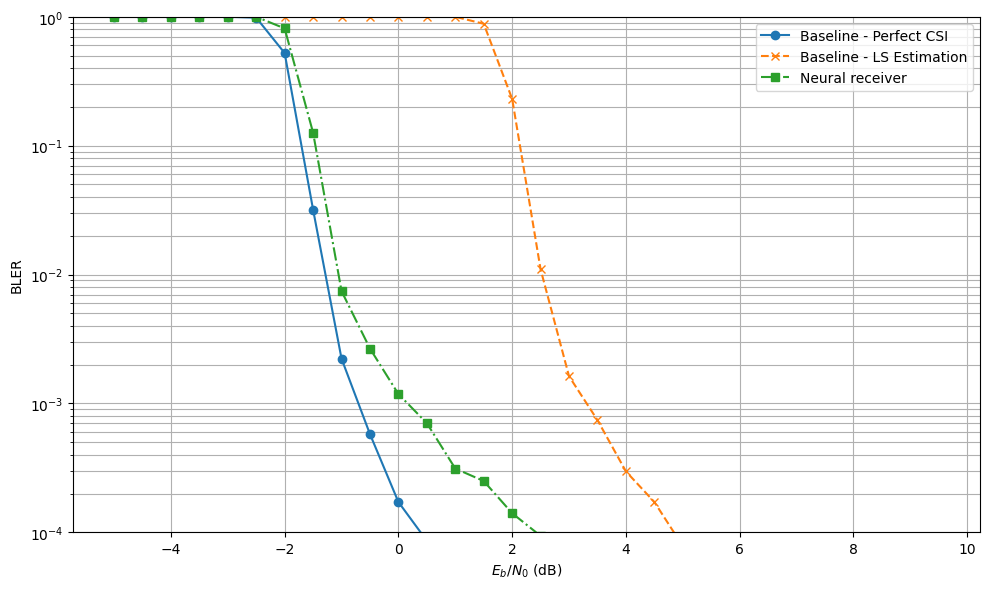

In [27]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
# Baseline - Perfect CSI
plt.semilogy(ebno_dbs, BLER['baseline-perfect-csi'], 'o-', c=f'C0', label=f'Baseline - Perfect CSI')
# Baseline - LS Estimation
plt.semilogy(ebno_dbs, BLER['baseline-ls-estimation'], 'x--', c=f'C1', label=f'Baseline - LS Estimation')
# Neural receiver
plt.semilogy(ebno_dbs, BLER['neural-receiver'], 's-.', c=f'C2', label=f'Neural receiver')
#
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.legend()
plt.tight_layout()

We observe the 2.5dB SNR gain at 10^-3 BLER between Neural Receiver and LS Estimation-based LMMSE receiver. However, the performance comparison between Neural Receiver and the LMMSE Receiver diverges as SNR increases. This shows that when the random noise power becomes less a limitation, the mathematical-grouded LMMSE equalizer performs better than the approximation-based Neural receiver.

# Evaluation 2: Performance of the Model on different CDL channel model with different conditions

## Different Channel Models

In [32]:
cdl_models = ["A", "B", "C", "D", "E"]
for model in cdl_models:
    cdl_model = model
    rx = E2ESystem('neural-receiver').to(device)
    rx(1, torch.tensor([10.0], device=device))
    rx.nrx._orig_mod.load_state_dict(torch.load(model_weights_path))
    rx.eval()
    _, bler = sim_ber(rx, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=1000, target_bler=1e-4)
    BLER[cdl_model] = bler.cpu().numpy()


EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -5.0 | 2.5700e-01 | 1.0000e+00 |       45791 |      178176 |          128 |         128 |         0.2 |reached target block errors
     -4.5 | 2.4237e-01 | 1.0000e+00 |       43185 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -4.0 | 2.2549e-01 | 1.0000e+00 |       40177 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.5 | 2.0490e-01 | 1.0000e+00 |       36508 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.0 | 1.7839e-01 | 1.0000e+00 |       31784 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -2.5 | 1.3414e-01 | 1.0000e+00 |       23901 |      178176 |

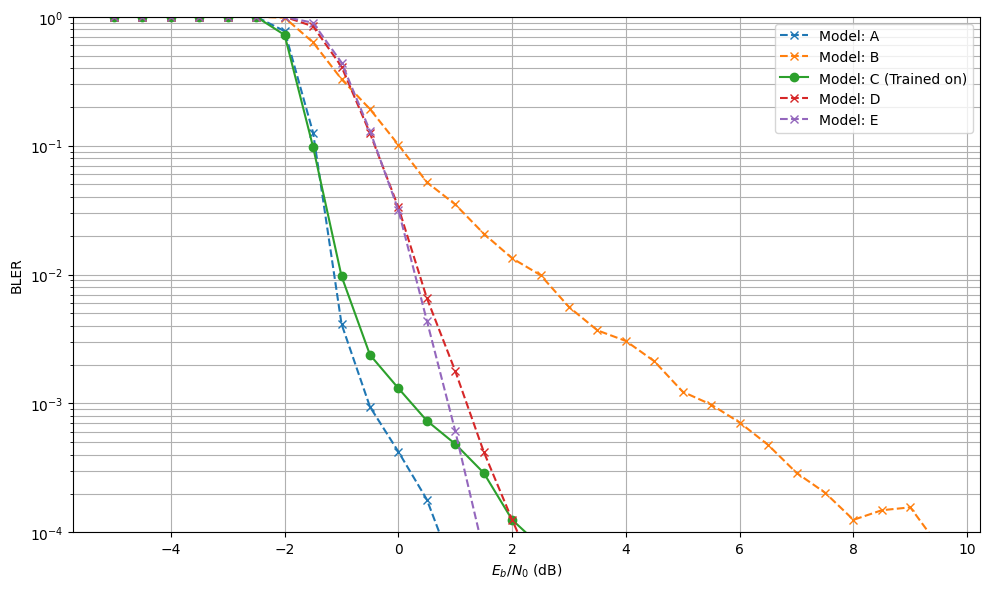

In [34]:
plt.figure(figsize=(10,6))
# Baseline - Perfect CSI
for model in cdl_models:
    if model == "C":
        plt.semilogy(ebno_dbs, BLER[model], 'o-', label=f"Model: {model} (Trained on)")
    else:
        plt.semilogy(ebno_dbs, BLER[model], 'x--', label=f"Model: {model}")
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.legend()
plt.tight_layout()

The receiver generalizes almost perfectly across model C, D and E. It also performs slightly better on A-model. B-model is the only model that the receiver cannot generalize.

We can observe that across all standard 3GPP CDL channel models, the neural receiver maintains a maximum performance degradation of exactly 3.5 dB at a target BLER of $\approx 10^{-2}$.

To create a truly robust neural receiver, we can randomly feed the network with a randomized mix of difference channel models.

# Different Delay Spread

In [35]:
delay_spread = 300e-9
cdl_model = "C"
label = "C-300ns"
rx = E2ESystem('neural-receiver').to(device)
rx(1, torch.tensor([10.0], device=device))
rx.nrx._orig_mod.load_state_dict(torch.load(model_weights_path))
rx.eval()
_, bler = sim_ber(rx, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=1000, target_bler=1e-4)
BLER[label] = bler.cpu().numpy()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -5.0 | 3.2008e-01 | 1.0000e+00 |       57030 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -4.5 | 3.0483e-01 | 1.0000e+00 |       54313 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -4.0 | 2.9227e-01 | 1.0000e+00 |       52075 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.5 | 2.8378e-01 | 1.0000e+00 |       50563 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.0 | 2.6252e-01 | 1.0000e+00 |       46775 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -2.5 | 2.4452e-01 | 1.0000e+00 |       43567 |      178176 |

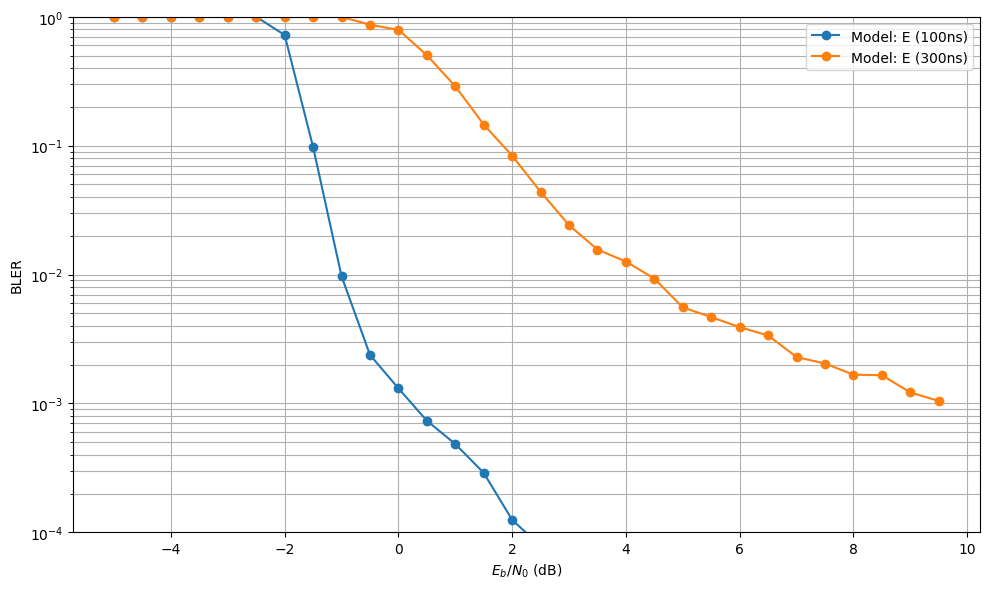

In [37]:
plt.figure(figsize=(10,6))
plt.semilogy(ebno_dbs, BLER["C"], 'o-', label=f"Model: {model} (100ns)")
plt.semilogy(ebno_dbs, BLER["C-300ns"], 'o-', label=f"Model: {model} (300ns)")
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.legend()
plt.tight_layout()

We can observe that the receiver performs much worse in high-delay spread just as in traditional receivers.

# Step 5: Finetune the pretrained Neural Receiver

In [65]:
from sionna.phy.utils import compute_bler
torch.cuda.empty_cache()
# Evaluation model
cdl_model = "B"
model_eval = E2ESystem(system="neural-receiver", training=False).to(device)
model_eval(1, torch.tensor([10.0], device=device))
model_eval.nrx._orig_mod.load_state_dict(torch.load(model_weights_path))

# Training model
model_train = E2ESystem(system="neural-receiver", training=True).to(device)
model_train.nrx = model_eval.nrx
optimizer = torch.optim.Adam(model_train.nrx.parameters(), lr=1e-5)

# Configuration
total_steps = 1000
eval_interval = 50

# We evaluate at a specific EbNo index
ebno_idx = 15
target_ebno = ebno_dbs[15]
baseline_bler = BLER["B"][15]
print(f"Baseline BLER at {target_ebno.item()}dB: {baseline_bler:.5f}")
ebno_db = torch.empty(1, device=device)
gains = []
steps = []
for step in range(1, total_steps + 1):
    model_train.train()

    ebno_db.uniform_(ebno_db_min, ebno_db_max)

    optimizer.zero_grad()

    rate = model_train(batch_size=training_batch_size, ebno_db=ebno_db)
    loss = -rate
    loss.backward()
    optimizer.step()

    # --- Evaluation Phase ---
    if step % eval_interval == 0:
        model_eval.eval()
        total_errors = 0
        with torch.no_grad():
            # Get decoded bits
            for _ in range(100):
                bits, b_hat = model_eval(batch_size=128, ebno_db=target_ebno)
                errors = compute_bler(bits, b_hat) * 128
                total_errors += errors
            bler = total_errors / (128*100)
            gain = baseline_bler - bler
            gains.append(gain)
            steps.append(step)
            print(f"Step {step:4d} | Loss: {loss.item():.4f} | BLER: {bler:.5f} | Gain: {gain:.5f}")

Baseline BLER at 2.5dB: 0.00989
Step   50 | Loss: -0.8113 | BLER: 0.03250 | Gain: -0.02261
Step  100 | Loss: -0.8449 | BLER: 0.02078 | Gain: -0.01089
Step  150 | Loss: -0.5486 | BLER: 0.01773 | Gain: -0.00785
Step  200 | Loss: -0.4659 | BLER: 0.01781 | Gain: -0.00792
Step  250 | Loss: -0.9713 | BLER: 0.01320 | Gain: -0.00331
Step  300 | Loss: -0.5770 | BLER: 0.01180 | Gain: -0.00191
Step  350 | Loss: -0.9494 | BLER: 0.00781 | Gain: 0.00208
Step  400 | Loss: -0.9688 | BLER: 0.00758 | Gain: 0.00231
Step  450 | Loss: -0.6826 | BLER: 0.00711 | Gain: 0.00278
Step  500 | Loss: -0.7669 | BLER: 0.00586 | Gain: 0.00403
Step  550 | Loss: -0.3438 | BLER: 0.00445 | Gain: 0.00544
Step  600 | Loss: -0.5810 | BLER: 0.00500 | Gain: 0.00489
Step  650 | Loss: -0.9839 | BLER: 0.00500 | Gain: 0.00489
Step  700 | Loss: -0.9635 | BLER: 0.00359 | Gain: 0.00630
Step  750 | Loss: -0.9573 | BLER: 0.00422 | Gain: 0.00567
Step  800 | Loss: -0.5893 | BLER: 0.00344 | Gain: 0.00645
Step  850 | Loss: -0.7840 | BLER: 

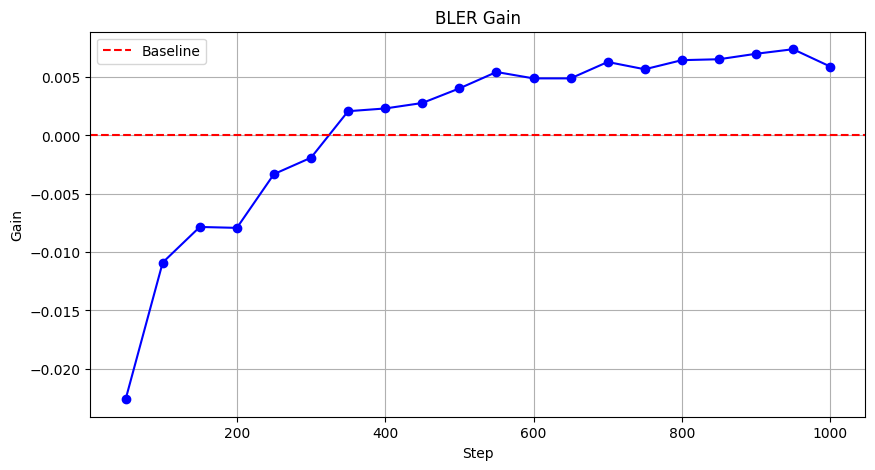

In [73]:
steps_plot = [s.item() if torch.is_tensor(s) else s for s in steps]
gains_plot = [g.item() if torch.is_tensor(g) else g for g in gains]

plt.figure(figsize=(10, 5))
plt.plot(steps_plot, gains_plot, marker='o', linestyle='-', color='b')
plt.axhline(y=0, color='r', linestyle='--', label='Baseline') # Red line for baseline
plt.title("BLER Gain")
plt.xlabel("Step")
plt.ylabel("Gain")
plt.grid(True)
plt.legend()
plt.show()

Initial results show a +0.0075 BLER  (~3x reduction in error rate) at 2.5dB after 1000 steps of domain adaptation. This serves as a proof-of-concept for the transfer learning approach.

A full SNR sweep can be implemented next to verify the gain across the entire waterfall curve.

Compression experiments using pruning and INT8 weight storage were started as exploratory work. Since true INT8 inference requires a dedicated quantized model, this is left as future work.

However, if you are willing to read my ongoing prototype in the next cells, a relatively small loss of about 0.5 dB at a BLER of $10^{-3}$ can be observed as initial performance evaluation.

# Step 6: Quantization and Pruning



Changing FP32 to INT8 is not just `model.to(torch.int8)`. PyTorch convolution layers normally expect floating-point inputs and floating-point weights. Real INT8 inference needs a new modified model that knows how to run INT8 convolution kernels.

Therefore, the following experiment studies only weight compression error, not accelerated INT8 inference.

In [120]:
import copy
from pathlib import Path

import torch.nn.utils.prune as prune


def file_size_mb(path):
    return Path(path).stat().st_size / (1024 ** 2)


test_y = torch.randn(2, 2, 14, 128, dtype=torch.complex64, device=device)
test_no = torch.tensor([0.01], dtype=torch.float32, device=device)


e2e = E2ESystem(system="neural-receiver", training=False).to(device)
e2e(1, torch.tensor([10.0], device=device))

# Get the actual neural receiver module.
# load_state_dict(...) loads weights into the model, but it does not return the model.
nrx_fp32 = e2e.nrx._orig_mod if hasattr(e2e.nrx, "_orig_mod") else e2e.nrx
nrx_fp32.load_state_dict(torch.load(model_weights_path, map_location=device))
nrx_fp32.eval()

with torch.no_grad():
    fp32_output = nrx_fp32(test_y, test_no)

print("FP32 model loaded")
print("Output shape:", tuple(fp32_output.shape))
print(f"Original FP32 checkpoint size: {file_size_mb(model_weights_path):.2f} MiB")


FP32 model loaded
Output shape: (2, 14, 128, 2)
Original FP32 checkpoint size: 18.55 MiB


In [121]:
# Pruning means: choose some small weights and set them to exactly zero.
# Here we prune 30% of the convolution weights.
# Important: this does NOT make the normal PyTorch state_dict smaller.
# It is still a dense tensor file; it just contains more zeros.
prune_amount = 0.30

nrx_pruned = copy.deepcopy(nrx_fp32).eval()

conv_layers = []
for name, layer in nrx_pruned.named_modules():
    if isinstance(layer, nn.Conv2d):
        conv_layers.append((name, layer))

parameters_to_prune = [(layer, "weight") for name, layer in conv_layers]

prune.global_unstructured(
    parameters_to_prune,
    pruning_method=prune.L1Unstructured,
    amount=prune_amount,
)

# Make pruning permanent. After this, zero weights are just normal zero values.
for name, layer in conv_layers:
    prune.remove(layer, "weight")

# Count how many parameters are now zero.
total_params = 0
zero_params = 0
for parameter in nrx_pruned.parameters():
    total_params += parameter.numel()
    zero_params += torch.count_nonzero(parameter == 0).item()

sparsity = zero_params / total_params

with torch.no_grad():
    pruned_output = nrx_pruned(test_y, test_no)
    pruning_error = torch.mean((fp32_output - pruned_output) ** 2).item()

pruned_path = Path(f"{model_weights_path}_pruned")
torch.save(nrx_pruned.state_dict(), pruned_path)

print(f"Pruned Conv2d layers: {len(conv_layers)}")
print(f"Zero parameters: {sparsity:.2%}")
print(f"MSE difference from FP32 output: {pruning_error:.4e}")
print(f"Saved dense pruned model to: {pruned_path}")


Pruned Conv2d layers: 10
Zero parameters: 7.59%
MSE difference from FP32 output: 9.3917e+00
Saved dense pruned model to: neural_receiver_weights_pruned


In [122]:
# This cell saves TWO files:
#
# 1. A runnable model file.
#    It is FP32 again, because normal Conv2d wants FP32 weights.
#    This file will be about the same size as the original.
#
# 2. A real INT8 weight-storage file.
#    This stores weight tensors as int8 plus one scale per tensor.
#    This file should be much smaller, but it is not directly loadable as a normal model.


def quantize_tensor_to_int8(tensor):
    max_value = tensor.abs().max()

    if max_value == 0:
        scale = torch.tensor(1.0, device=tensor.device)
    else:
        scale = max_value / 127.0

    int8_tensor = torch.round(tensor / scale).clamp(-127, 127).to(torch.int8)
    return int8_tensor, scale


def dequantize_int8_to_fp32(int8_tensor, scale):
    return int8_tensor.float() * scale


nrx_dequantized = copy.deepcopy(nrx_pruned).eval()
int8_checkpoint = {}

for name, parameter in nrx_dequantized.named_parameters():
    if "weight" in name:
        int8_value, scale = quantize_tensor_to_int8(parameter.data)

        # Save the small INT8 representation.
        int8_checkpoint[name] = {
            "int8_value": int8_value.cpu(),
            "scale": scale.cpu(),
        }

        # Put FP32 weights back into the runnable PyTorch model.
        parameter.data = dequantize_int8_to_fp32(int8_value, scale).to(device)
    else:
        # Keep biases as FP32
        int8_checkpoint[name] = {
            "fp32_value": parameter.data.cpu(),
        }

with torch.no_grad():
    dequantized_output = nrx_dequantized(test_y, test_no)
    quantization_error = torch.mean((pruned_output - dequantized_output) ** 2).item()

runnable_quantized_path = Path(f"{model_weights_path}_pruned_dequantized_from_int8")
int8_weights_path = Path(f"{model_weights_path}_int8_weights_only")

torch.save(nrx_dequantized.state_dict(), runnable_quantized_path)
torch.save(int8_checkpoint, int8_weights_path)

print(f"MSE difference from pruned output: {quantization_error:.4e}")
print(f"Saved runnable dequantized model to: {runnable_quantized_path}")
print(f"Runnable dequantized model size: {file_size_mb(runnable_quantized_path):.2f} MiB")
print(f"Saved real INT8 weight-storage file to: {int8_weights_path}")
print(f"INT8 weight-storage file size: {file_size_mb(int8_weights_path):.2f} MiB")


MSE difference from pruned output: 4.0656e-02
Saved runnable dequantized model to: neural_receiver_weights_pruned_dequantized_from_int8
Runnable dequantized model size: 18.55 MiB
Saved real INT8 weight-storage file to: neural_receiver_weights_int8_weights_only
INT8 weight-storage file size: 9.90 MiB


In [130]:
gc.collect()
torch.cuda.empty_cache()
cdl_model = "C"
delay_spread = 100e-9
model = E2ESystem('neural-receiver').to(device)
# Run one inference to build the layers and load the weights
model(1, torch.tensor([10.0], device=device))
model.nrx._orig_mod.load_state_dict(torch.load(f"{model_weights_path}_pruned_dequantized_from_int8"))
model.eval()

# Evaluations
_, bler = sim_ber(model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=1000, target_bler=1e-4)
BLER['quantized_model'] = bler.cpu().numpy()

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     -5.0 | 2.8620e-01 | 1.0000e+00 |       50994 |      178176 |          128 |         128 |         0.2 |reached target block errors
     -4.5 | 2.7226e-01 | 1.0000e+00 |       48511 |      178176 |          128 |         128 |         0.2 |reached target block errors
     -4.0 | 2.5033e-01 | 1.0000e+00 |       44603 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.5 | 2.3281e-01 | 1.0000e+00 |       41482 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -3.0 | 2.1031e-01 | 1.0000e+00 |       37473 |      178176 |          128 |         128 |         0.1 |reached target block errors
     -2.5 | 1.8441e-01 | 1.0000e+00 |       32857 |      178176 |

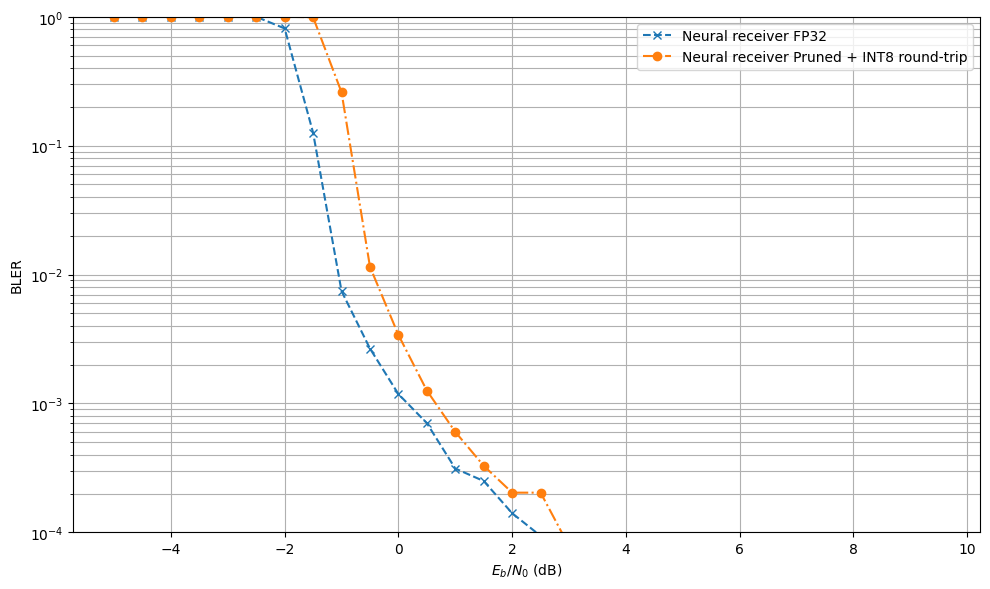

In [131]:
plt.figure(figsize=(10,6))
plt.semilogy(ebno_dbs, BLER['neural-receiver'], 'x--', label=f'Neural receiver FP32')
plt.semilogy(ebno_dbs, BLER['quantized_model'], 'o-.', label=f'Neural receiver Pruned + INT8 round-trip')
plt.xlabel(r"$E_b/N_0$ (dB)")
plt.ylabel("BLER")
plt.grid(which="both")
plt.ylim((1e-4, 1.0))
plt.legend()
plt.tight_layout()

Pruning and quantization do not appear to significantly degrade the BLER performance. The main observable impact is a relatively small loss of about 0.5 dB at a BLER of $10^{-3}$, which suggests that the compressed model still preserves most of the original performance. However, as stated above, this is a compression-error study, not a true INT8 inference benchmark.
